# CS3807 – Deep Learning Laboratory · Experiment 7
## End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

**Dataset:** MNIST (10,000 train → 9,000 train / 1,000 validation, 2,000 test)  

| Task | Content |
|---|---|
| 0 | Setup, data preparation, helper functions |
| 1 | Fully connected autoencoder (Plots 1, 2 + metrics) |
| 2 | Convolutional autoencoder and FC vs CAE comparison (Plot 3) |
| 3 | Denoising convolutional autoencoder (Plots 4, 5) |
| 4 | Variational autoencoder – model and training (VAE loss plot) |
| 5 | VAE latent space, generation and interpolation (Plots 6, 7, 8) |
| 6 | Reconstruction-error distribution and high-error images |
| 7 | Latent-dimension study (Plot 10) |
| 8 | Consolidated results and written inferences |

Run the cells top to bottom. All figures are saved in `figs/` and all tables in `results/`.

---
# Task 0 · Setup and Data Preparation
Pixel values are scaled from [0, 255] to [0, 1]. Labels are **not** used as reconstruction targets (only for latent-space colouring).

In [ ]:
# Uncomment if running on a fresh environment (Colab already has TensorFlow)
# !pip install -q tensorflow scikit-image pandas matplotlib

In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, ops
from skimage.metrics import structural_similarity as ssim_fn

SEED = 42
keras.utils.set_random_seed(SEED)
os.makedirs("figs", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


In [ ]:
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = keras.datasets.mnist.load_data()

x_all   = (x_tr_full[:10000].astype("float32") / 255.0)[..., None]
x_train, x_val = x_all[:9000], x_all[9000:]
x_test  = (x_te_full[:2000].astype("float32") / 255.0)[..., None]
y_test  = y_te_full[:2000]

print("train:", x_train.shape, "| val:", x_val.shape, "| test:", x_test.shape)
print("pixel range:", x_train.min(), "-", x_train.max())

flat = lambda a: a.reshape(len(a), -1)     # 28x28x1 -> 784
EPOCHS, BATCH = 20, 128

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train: (9000, 28, 28, 1) | val: (1000, 28, 28, 1) | test: (2000, 28, 28, 1)
pixel range: 0.0 - 1.0


In [ ]:
# ---------- Helper functions ----------
def savefig(name):
    plt.tight_layout()
    plt.savefig(f"figs/{name}.png", dpi=150)
    plt.show()

def per_image_mse(x, xh):
    return np.mean((x - xh) ** 2, axis=(1, 2, 3))

def mean_ssim(x, xh):
    return float(np.mean([ssim_fn(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xh)]))

def evaluate(x, xh):
    """Test MSE, MAE and mean SSIM between originals x and reconstructions xh."""
    return dict(MSE=float(np.mean((x - xh) ** 2)),
                MAE=float(np.mean(np.abs(x - xh))),
                SSIM=mean_ssim(x, xh))

def show_rows(rows, titles, n=10, name=None):
    """Grid: one row of n images per entry in `rows`."""
    fig, axes = plt.subplots(len(rows), n, figsize=(1.4 * n, 1.7 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for i in range(n):
            axes[r, i].imshow(imgs[i].squeeze(), cmap="gray", vmin=0, vmax=1)
            axes[r, i].axis("off")
        axes[r, 0].set_title(t, fontsize=9, loc="left")
    if name: savefig(name)

results = {}     # filled progressively; used in Task 8

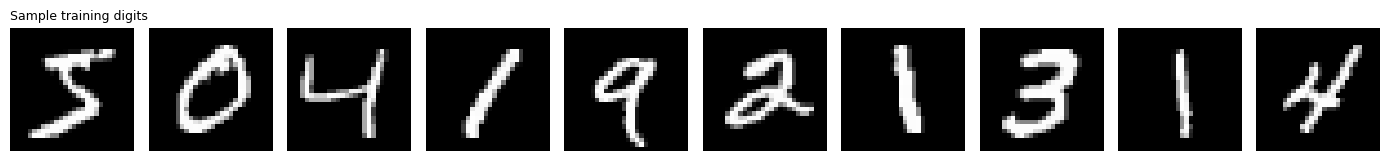

In [ ]:
# Quick look at the data
show_rows([x_train[:10]], ["Sample training digits"], name="data_samples")

---
# Task 1 · Fully Connected Autoencoder
**Architecture:** 784 → 128 → 32 → **16 (latent)** → 32 → 128 → 784  
ReLU in hidden layers, sigmoid output · Adam (lr = 1e-3) · batch 128 · 20 epochs · Binary cross-entropy.

In [ ]:
def build_fc_ae(latent=16):
    inp = keras.Input((784,))
    h = layers.Dense(128, activation="relu")(inp)
    h = layers.Dense(32, activation="relu")(h)
    z = layers.Dense(latent, name="latent")(h)
    h = layers.Dense(32, activation="relu")(z)
    h = layers.Dense(128, activation="relu")(h)
    out = layers.Dense(784, activation="sigmoid")(h)
    m = keras.Model(inp, out, name=f"fc_ae_{latent}")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m

def train_fc(latent=16, verbose=0):
    m = build_fc_ae(latent)
    t0 = time.time()
    h = m.fit(flat(x_train), flat(x_train), epochs=EPOCHS, batch_size=BATCH,
              validation_data=(flat(x_val), flat(x_val)), shuffle=True, verbose=verbose)
    return m, h.history, time.time() - t0

fc_ae = build_fc_ae(16)
fc_ae.summary()

Model: "fc_ae_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
fc_ae, fc_hist, fc_time = train_fc(16, verbose=2)
print(f"Training time: {fc_time:.1f} s")

Epoch 1/20
71/71 - 9s - 131ms/step - loss: 0.3516 - val_loss: 0.2606
Epoch 2/20
71/71 - 0s - 4ms/step - loss: 0.2299 - val_loss: 0.2075
Epoch 3/20
71/71 - 0s - 6ms/step - loss: 0.1924 - val_loss: 0.1845
Epoch 4/20
71/71 - 1s - 9ms/step - loss: 0.1720 - val_loss: 0.1697
Epoch 5/20
71/71 - 0s - 6ms/step - loss: 0.1612 - val_loss: 0.1615
Epoch 6/20
71/71 - 0s - 6ms/step - loss: 0.1529 - val_loss: 0.1545
Epoch 7/20
71/71 - 0s - 6ms/step - loss: 0.1460 - val_loss: 0.1488
Epoch 8/20
71/71 - 0s - 5ms/step - loss: 0.1410 - val_loss: 0.1448
Epoch 9/20
71/71 - 0s - 4ms/step - loss: 0.1375 - val_loss: 0.1420
Epoch 10/20
71/71 - 0s - 4ms/step - loss: 0.1348 - val_loss: 0.1398
Epoch 11/20
71/71 - 0s - 4ms/step - loss: 0.1326 - val_loss: 0.1380
Epoch 12/20
71/71 - 0s - 4ms/step - loss: 0.1308 - val_loss: 0.1365
Epoch 13/20
71/71 - 0s - 4ms/step - loss: 0.1292 - val_loss: 0.1350
Epoch 14/20
71/71 - 0s - 4ms/step - loss: 0.1275 - val_loss: 0.1335
Epoch 15/20
71/71 - 0s - 4ms/step - loss: 0.1259 - val_

### Plot 1 · Original vs Reconstruction vs Error

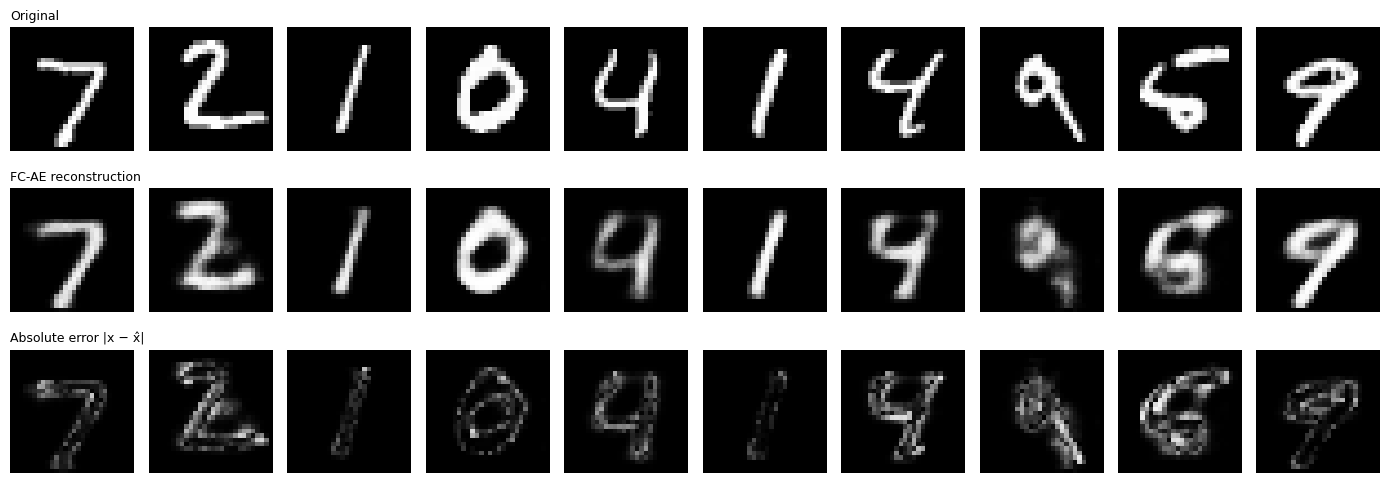

In [ ]:
fc_rec = fc_ae.predict(flat(x_test), verbose=0).reshape(-1, 28, 28, 1)

show_rows([x_test[:10], fc_rec[:10], np.abs(x_test[:10] - fc_rec[:10])],
          ["Original", "FC-AE reconstruction", "Absolute error |x − x̂|"],
          name="plot1_fc_reconstruction")

### Plot 2 · Training and Validation Reconstruction Loss

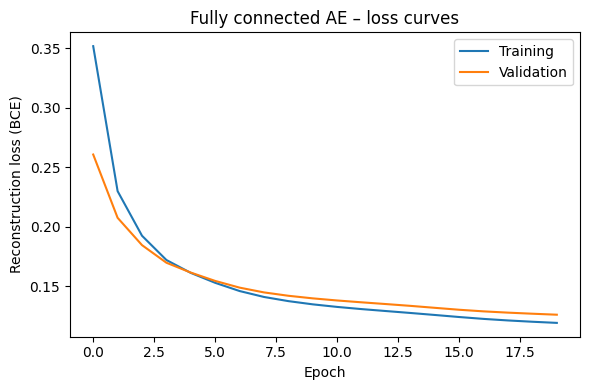

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(fc_hist["loss"], label="Training")
plt.plot(fc_hist["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss (BCE)")
plt.title("Fully connected AE – loss curves"); plt.legend()
savefig("plot2_fc_loss")

### Reconstruction metrics (test set)

In [ ]:
fc_metrics = evaluate(x_test, fc_rec)
fc_df = pd.DataFrame({"Metric": ["Test MSE", "Test MAE", "Mean SSIM"],
                      "Value": [fc_metrics["MSE"], fc_metrics["MAE"], fc_metrics["SSIM"]]})
display(fc_df)
results["FC Autoencoder"] = dict(**fc_metrics, Parameters=fc_ae.count_params(), Time_s=fc_time)

,Metric,Value
0,Test MSE,0.020462
1,Test MAE,0.055104
2,Mean SSIM,0.758710


### ✍️ Inference – Task 1
*Plot 1:* preservation of digit shape, loss of fine details, blurred regions, easy vs difficult samples.  
*Plot 2:* does the model converge? Is there evidence of overfitting (gap between train and validation)?

> **Write your inference here (what / trend / why / conclusion).**

---
# Task 2 · Convolutional Autoencoder (CAE) and Comparison with FC-AE
The CAE keeps the 2-D spatial structure. Encoder: Conv-Pool-Conv-Pool → 7×7×64 latent feature map; decoder: UpSampling + Conv.

In [ ]:
def build_cae():
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)      # latent feature map 7x7x64
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    m = keras.Model(inp, out, name="cae")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m

cae = build_cae()
cae.summary()

Model: "cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 - 8s - 111ms/step - loss: 0.2618 - val_loss: 0.1141
Epoch 2/20
71/71 - 1s - 8ms/step - loss: 0.0954 - val_loss: 0.0900
Epoch 3/20
71/71 - 1s - 9ms/step - loss: 0.0844 - val_loss: 0.0834
Epoch 4/20
71/71 - 1s - 9ms/step - loss: 0.0800 - val_loss: 0.0799
Epoch 5/20
71/71 - 1s - 9ms/step - loss: 0.0772 - val_loss: 0.0775
Epoch 6/20
71/71 - 1s - 16ms/step - loss: 0.0754 - val_loss: 0.0762
Epoch 7/20
71/71 - 1s - 7ms/step - loss: 0.0740 - val_loss: 0.0760
Epoch 8/20
71/71 - 1s - 7ms/step - loss: 0.0731 - val_loss: 0.0747
Epoch 9/20
71/71 - 1s - 7ms/step - loss: 0.0724 - val_loss: 0.0740
Epoch 10/20
71/71 - 1s - 7ms/step - loss: 0.0717 - val_loss: 0.0728
Epoch 11/20
71/71 - 1s - 7ms/step - loss: 0.0712 - val_loss: 0.0723
Epoch 12/20
71/71 - 1s - 8ms/step - loss: 0.0707 - val_loss: 0.0718
Epoch 13/20
71/71 - 1s - 7ms/step - loss: 0.0703 - val_loss: 0.0714
Epoch 14/20
71/71 - 1s - 8ms/step - loss: 0.0699 - val_loss: 0.0710
Epoch 15/20
71/71 - 1s - 7ms/step - loss: 0.0696 - val

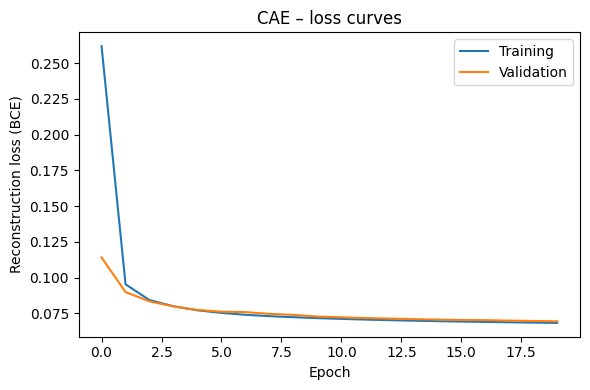

In [ ]:
t0 = time.time()
cae_hist = cae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH,
                   validation_data=(x_val, x_val), shuffle=True, verbose=2).history
cae_time = time.time() - t0
print(f"Training time: {cae_time:.1f} s")

plt.figure(figsize=(6, 4))
plt.plot(cae_hist["loss"], label="Training"); plt.plot(cae_hist["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss (BCE)"); plt.title("CAE – loss curves"); plt.legend()
savefig("cae_loss")

In [ ]:
cae_rec = cae.predict(x_test, verbose=0)
cae_metrics = evaluate(x_test, cae_rec)
results["Conv. Autoencoder"] = dict(**cae_metrics, Parameters=cae.count_params(), Time_s=cae_time)

comparison = pd.DataFrame({
    "Fully Connected AE": {**fc_metrics,  "Parameters": fc_ae.count_params()},
    "Convolutional AE":   {**cae_metrics, "Parameters": cae.count_params()}}).T
display(comparison)
comparison.to_csv("results/fc_vs_cae.csv")

,MSE,MAE,SSIM,Parameters
Fully Connected AE,0.020462,0.055104,0.758710,211040.0
Convolutional AE,0.002598,0.015094,0.973521,74497.0


### Plot 3 · Original → FC-AE → CAE

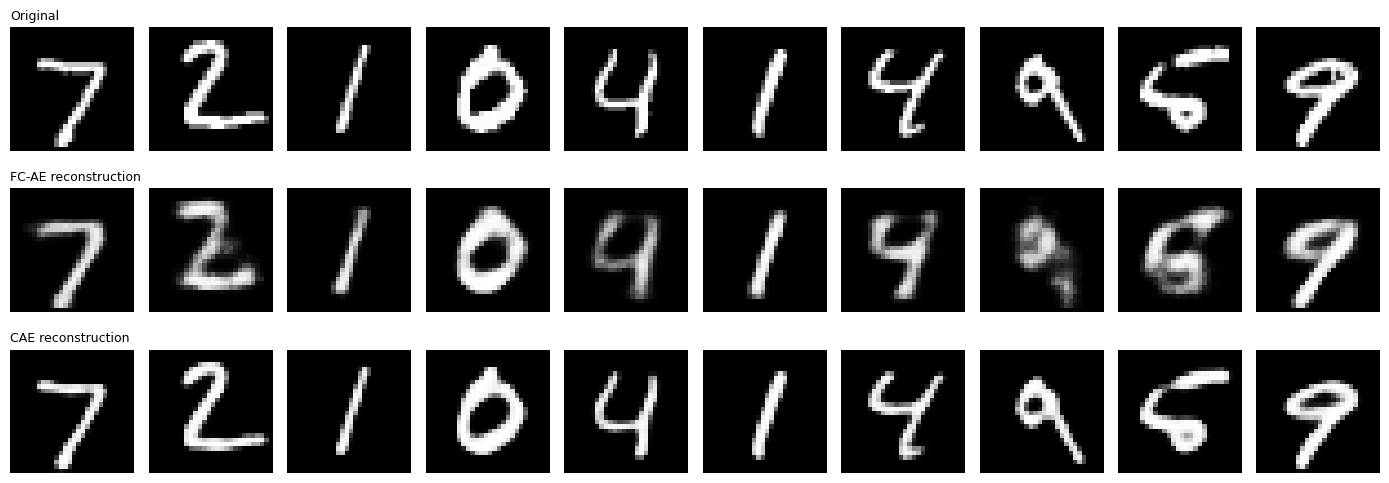

In [ ]:
show_rows([x_test[:10], fc_rec[:10], cae_rec[:10]],
          ["Original", "FC-AE reconstruction", "CAE reconstruction"],
          name="plot3_fc_vs_cae")

### ✍️ Inference – Task 2
Discuss how preserving spatial locality (weight sharing, local receptive fields) affects reconstruction quality, and relate it to the parameter counts.

> **Write your inference here.**

---
# Task 3 · Denoising Convolutional Autoencoder
Input = noisy image x̃, **target = clean image x**.  
Two corruptions: Gaussian noise (σ ∈ {0.1, 0.2, 0.3}, clipped to [0,1]) and salt-and-pepper (p ∈ {0.05, 0.10, 0.20}).

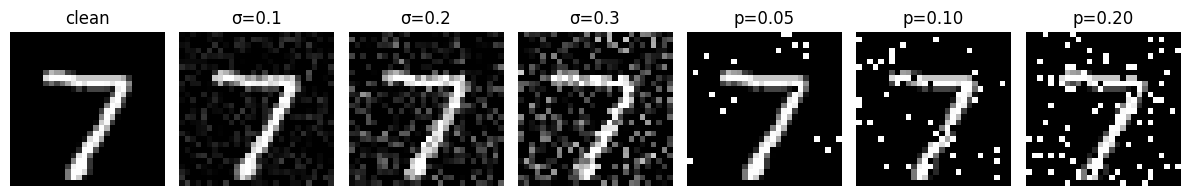

In [ ]:
def gaussian_noise(x, sigma, g):
    return np.clip(x + g.normal(0, sigma, x.shape), 0, 1).astype("float32")

def salt_pepper(x, p, g):
    m = g.random(x.shape)
    out = x.copy()
    out[m < p / 2] = 0.0                       # pepper
    out[(m >= p / 2) & (m < p)] = 1.0          # salt
    return out.astype("float32")

# visualise the corruption levels on one digit
g = np.random.default_rng(0)
demo = x_test[:1]
noisy_demo = [gaussian_noise(demo, s, g) for s in (0.1, 0.2, 0.3)] + \
             [salt_pepper(demo, p, g) for p in (0.05, 0.10, 0.20)]
fig, axes = plt.subplots(1, 7, figsize=(12, 2))
axes[0].imshow(demo[0, ..., 0], cmap="gray"); axes[0].set_title("clean")
for a, im, t in zip(axes[1:], noisy_demo,
                    ["σ=0.1", "σ=0.2", "σ=0.3", "p=0.05", "p=0.10", "p=0.20"]):
    a.imshow(im[0, ..., 0], cmap="gray", vmin=0, vmax=1); a.set_title(t)
for a in axes: a.axis("off")
savefig("noise_examples")

In [ ]:
def train_denoiser(noise_fn, label):
    # Fresh noise is drawn every epoch; the target is always the clean image.
    g = np.random.default_rng(SEED)
    m = build_cae()
    hist = {"loss": [], "val_loss": []}
    t0 = time.time()
    for ep in range(EPOCHS):
        h = m.fit(noise_fn(x_train, g), x_train, epochs=1, batch_size=BATCH,
                  validation_data=(noise_fn(x_val, g), x_val), shuffle=True, verbose=0)
        hist["loss"].append(h.history["loss"][0])
        hist["val_loss"].append(h.history["val_loss"][0])
        print(f"[{label}] epoch {ep+1:2d}/{EPOCHS}  loss={hist['loss'][-1]:.4f}  val={hist['val_loss'][-1]:.4f}")
    return m, hist, time.time() - t0

dae_g,  dae_g_hist,  dae_g_time  = train_denoiser(lambda x, g: gaussian_noise(x, 0.2, g), "Gaussian σ=0.2")

[Gaussian σ=0.2] epoch  1/20  loss=0.2649  val=0.1288
[Gaussian σ=0.2] epoch  2/20  loss=0.1100  val=0.1016
[Gaussian σ=0.2] epoch  3/20  loss=0.0945  val=0.0934
[Gaussian σ=0.2] epoch  4/20  loss=0.0895  val=0.0902
[Gaussian σ=0.2] epoch  5/20  loss=0.0861  val=0.0867
[Gaussian σ=0.2] epoch  6/20  loss=0.0839  val=0.0848
[Gaussian σ=0.2] epoch  7/20  loss=0.0824  val=0.0835
[Gaussian σ=0.2] epoch  8/20  loss=0.0815  val=0.0827
[Gaussian σ=0.2] epoch  9/20  loss=0.0805  val=0.0817
[Gaussian σ=0.2] epoch 10/20  loss=0.0796  val=0.0809
[Gaussian σ=0.2] epoch 11/20  loss=0.0792  val=0.0819
[Gaussian σ=0.2] epoch 12/20  loss=0.0788  val=0.0801
[Gaussian σ=0.2] epoch 13/20  loss=0.0780  val=0.0795
[Gaussian σ=0.2] epoch 14/20  loss=0.0776  val=0.0795
[Gaussian σ=0.2] epoch 15/20  loss=0.0773  val=0.0790
[Gaussian σ=0.2] epoch 16/20  loss=0.0770  val=0.0786
[Gaussian σ=0.2] epoch 17/20  loss=0.0767  val=0.0781
[Gaussian σ=0.2] epoch 18/20  loss=0.0764  val=0.0779
[Gaussian σ=0.2] epoch 19/20

In [ ]:
dae_sp, dae_sp_hist, dae_sp_time = train_denoiser(lambda x, g: salt_pepper(x, 0.10, g), "Salt&Pepper p=0.10")

[Salt&Pepper p=0.10] epoch  1/20  loss=0.2588  val=0.1339
[Salt&Pepper p=0.10] epoch  2/20  loss=0.1111  val=0.1004
[Salt&Pepper p=0.10] epoch  3/20  loss=0.0949  val=0.0942
[Salt&Pepper p=0.10] epoch  4/20  loss=0.0896  val=0.0898
[Salt&Pepper p=0.10] epoch  5/20  loss=0.0870  val=0.0875
[Salt&Pepper p=0.10] epoch  6/20  loss=0.0848  val=0.0859
[Salt&Pepper p=0.10] epoch  7/20  loss=0.0835  val=0.0847
[Salt&Pepper p=0.10] epoch  8/20  loss=0.0822  val=0.0836
[Salt&Pepper p=0.10] epoch  9/20  loss=0.0813  val=0.0827
[Salt&Pepper p=0.10] epoch 10/20  loss=0.0805  val=0.0816
[Salt&Pepper p=0.10] epoch 11/20  loss=0.0798  val=0.0812
[Salt&Pepper p=0.10] epoch 12/20  loss=0.0793  val=0.0806
[Salt&Pepper p=0.10] epoch 13/20  loss=0.0786  val=0.0801
[Salt&Pepper p=0.10] epoch 14/20  loss=0.0783  val=0.0793
[Salt&Pepper p=0.10] epoch 15/20  loss=0.0778  val=0.0792
[Salt&Pepper p=0.10] epoch 16/20  loss=0.0774  val=0.0786
[Salt&Pepper p=0.10] epoch 17/20  loss=0.0770  val=0.0785
[Salt&Pepper p

### Plot 4 · Clean | Noisy | Denoised

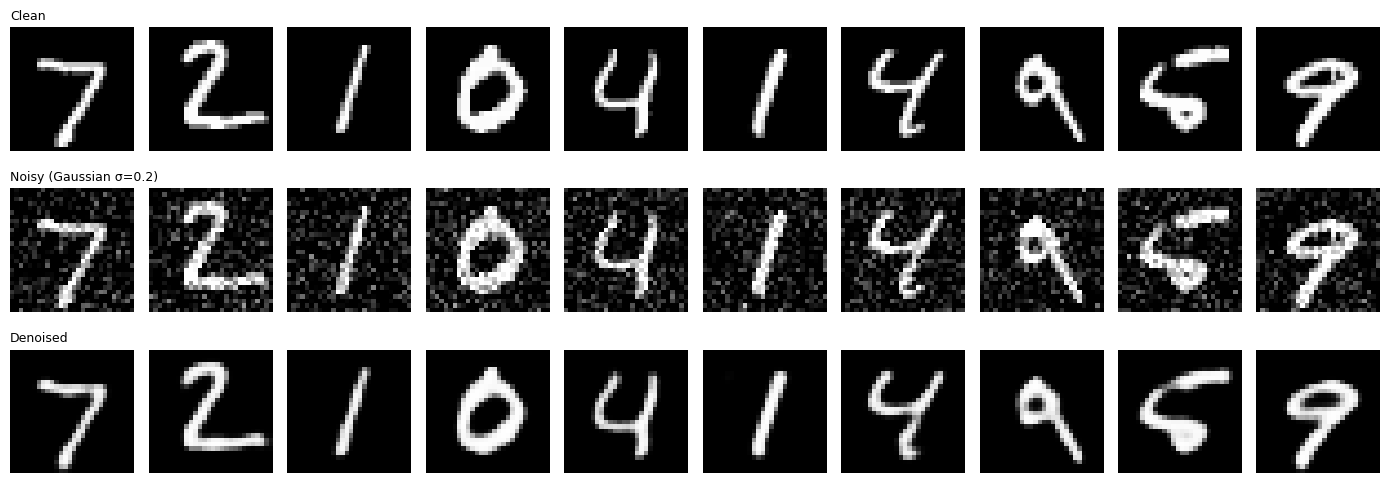

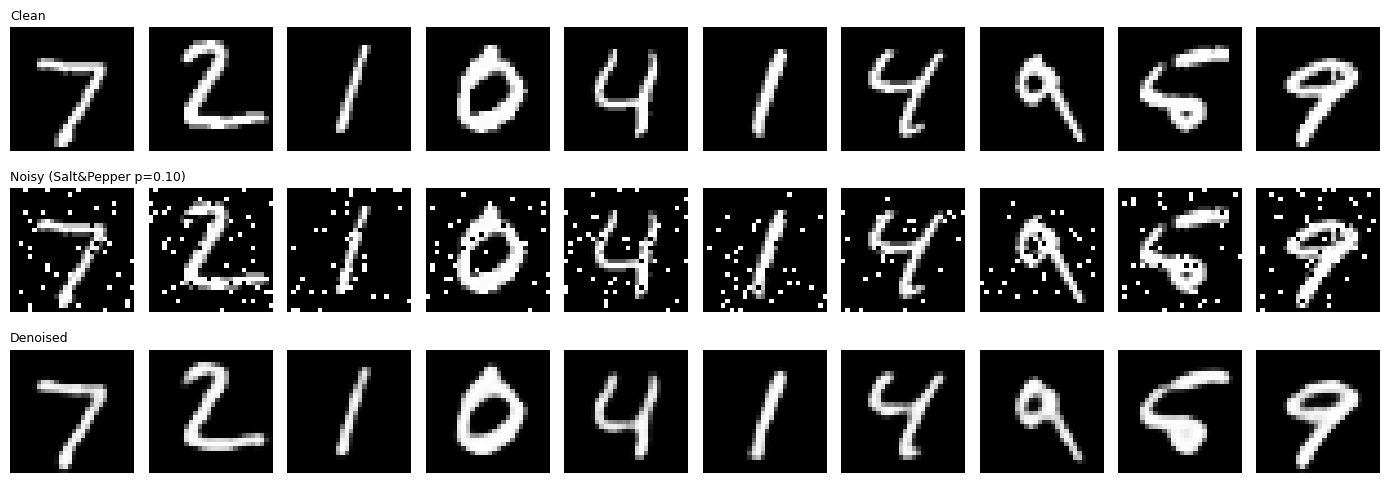

In [ ]:
g = np.random.default_rng(7)

xn_g = gaussian_noise(x_test[:10], 0.2, g)
show_rows([x_test[:10], xn_g, dae_g.predict(xn_g, verbose=0)],
          ["Clean", "Noisy (Gaussian σ=0.2)", "Denoised"], name="plot4_denoise_gaussian")

xn_s = salt_pepper(x_test[:10], 0.10, g)
show_rows([x_test[:10], xn_s, dae_sp.predict(xn_s, verbose=0)],
          ["Clean", "Noisy (Salt&Pepper p=0.10)", "Denoised"], name="plot4_denoise_saltpepper")

### Plot 5 · Noise level vs MSE / MAE / SSIM

In [ ]:
rows = []
for mname, model in [("Trained on Gaussian σ=0.2", dae_g), ("Trained on S&P p=0.10", dae_sp)]:
    for ntype, levels, fn in [("Gaussian", [0.1, 0.2, 0.3], gaussian_noise),
                              ("Salt&Pepper", [0.05, 0.10, 0.20], salt_pepper)]:
        for lv in levels:
            xn = fn(x_test, lv, np.random.default_rng(1000))
            xd = model.predict(xn, verbose=0)
            den, noisy = evaluate(x_test, xd), evaluate(x_test, xn)
            rows.append(dict(Model=mname, Noise=ntype, Level=lv,
                             MSE=den["MSE"], MAE=den["MAE"], SSIM=den["SSIM"],
                             Noisy_MSE=noisy["MSE"], Noisy_MAE=noisy["MAE"], Noisy_SSIM=noisy["SSIM"]))
noise_df = pd.DataFrame(rows)
noise_df.to_csv("results/noise_results.csv", index=False)
display(noise_df.round(4))

,Model,Noise,Level,MSE,MAE,SSIM,Noisy_MSE,Noisy_MAE,Noisy_SSIM
0,Trained on Gaussian σ=0.2,Gaussian,0.10,0.0037,0.0180,0.9588,0.0054,0.0440,0.6789
1,Trained on Gaussian σ=0.2,Gaussian,0.20,0.0047,0.0215,0.9443,0.0212,0.0865,0.5938
2,Trained on Gaussian σ=0.2,Gaussian,0.30,0.0072,0.0294,0.8747,0.0466,0.1279,0.5093
3,Trained on Gaussian σ=0.2,Salt&Pepper,0.05,0.0049,0.0214,0.9327,0.0241,0.0251,0.7090
4,Trained on Gaussian σ=0.2,Salt&Pepper,0.10,0.0071,0.0273,0.8835,0.0483,0.0502,0.5786
5,Trained on Gaussian σ=0.2,Salt&Pepper,0.20,0.0134,0.0422,0.7603,0.0958,0.0995,0.4476
6,Trained on S&P p=0.10,Gaussian,0.10,0.0073,0.0300,0.8738,0.0054,0.0440,0.6789
7,Trained on S&P p=0.10,Gaussian,0.20,0.0130,0.0490,0.6944,0.0212,0.0865,0.5938
8,Trained on S&P p=0.10,Gaussian,0.30,0.0203,0.0707,0.6000,0.0466,0.1279,0.5093
9,Trained on S&P p=0.10,Salt&Pepper,0.05,0.0041,0.0191,0.9560,0.0241,0.0251,0.7090


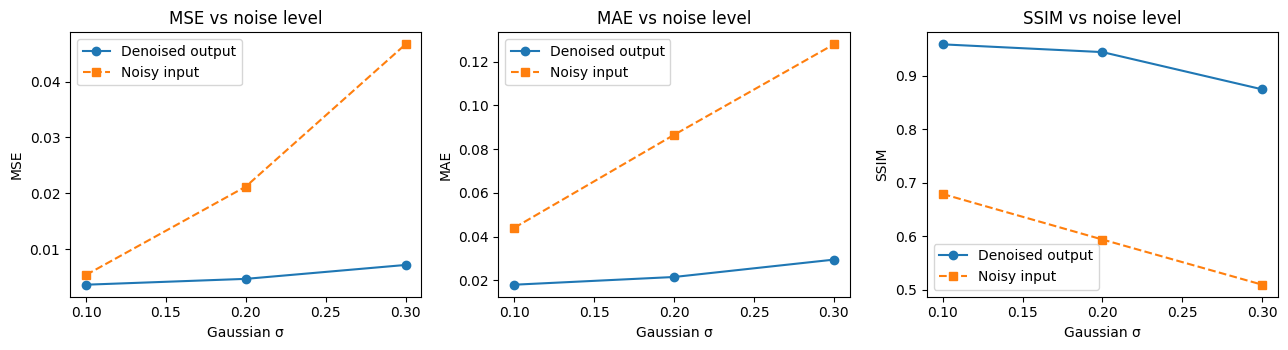

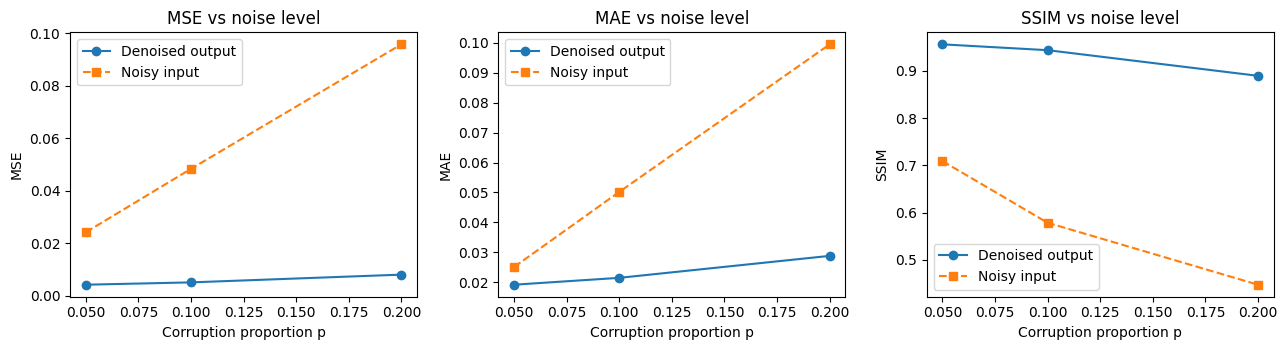

,Noise Level,MSE,MAE,SSIM
0,0.1,0.0037,0.0180,0.9588
1,0.2,0.0047,0.0215,0.9443
2,0.3,0.0072,0.0294,0.8747


In [ ]:
# Separate axes for each metric (incompatible scales are never mixed on one axis)
def plot_noise_curves(model_name, noise_type, xlabel, fname):
    sub = noise_df[(noise_df.Model == model_name) & (noise_df.Noise == noise_type)]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, met in zip(axes, ["MSE", "MAE", "SSIM"]):
        ax.plot(sub.Level, sub[met], "o-", label="Denoised output")
        ax.plot(sub.Level, sub["Noisy_" + met], "s--", label="Noisy input")
        ax.set_xlabel(xlabel); ax.set_ylabel(met); ax.set_title(f"{met} vs noise level"); ax.legend()
    savefig(fname)

plot_noise_curves("Trained on Gaussian σ=0.2", "Gaussian", "Gaussian σ", "plot5_gaussian_noise_vs_quality")
plot_noise_curves("Trained on S&P p=0.10", "Salt&Pepper", "Corruption proportion p", "plot5_saltpepper_noise_vs_quality")

sub = noise_df[(noise_df.Model == "Trained on Gaussian σ=0.2") & (noise_df.Noise == "Gaussian")]
display(sub[["Level", "MSE", "MAE", "SSIM"]].rename(columns={"Level": "Noise Level"}).round(4))

In [ ]:
# Denoising CAE row for the consolidated table (Gaussian σ = 0.2 vs clean target)
d = sub[sub.Level == 0.2].iloc[0]
results["Denoising CAE"] = dict(MSE=d.MSE, MAE=d.MAE, SSIM=d.SSIM,
                                Parameters=dae_g.count_params(), Time_s=dae_g_time)

### ✍️ Inference – Task 3
Effect of Gaussian noise level on MSE/MAE/SSIM; does the DAE recover the major digit structure? Compare Gaussian vs salt-and-pepper (Additional Exercise 2).

> **Write your inference here.**

---
# Task 4 · Variational Autoencoder – Model and Training
Encoder outputs **µ, log σ²** (2-D). Reparameterisation: **z = µ + σ ⊙ ε, ε ~ N(0, I)**.  
Loss = summed BCE reconstruction + KL( q(z|x) ‖ N(0, I) ), KL = −½ Σ(1 + log σ² − µ² − σ²).

In [ ]:
LATENT = 2

class Sampling(layers.Layer):
    """Reparameterisation trick."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch, dim = ops.shape(z_mean)[0], ops.shape(z_mean)[1]
        eps = keras.random.normal(shape=(batch, dim))
        return z_mean + ops.exp(0.5 * z_log_var) * eps

def build_vae_parts(latent=LATENT):
    enc_in = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(enc_in)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)
    z_mean    = layers.Dense(latent, name="z_mean")(x)
    z_log_var = layers.Dense(latent, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(enc_in, [z_mean, z_log_var, z], name="encoder")

    dec_in = keras.Input((latent,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(dec_in)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    dec_out = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    decoder = keras.Model(dec_in, dec_out, name="decoder")
    return encoder, decoder

encoder, decoder = build_vae_parts()
encoder.summary(); decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder, self.beta = encoder, decoder, beta
        self.total_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker   = keras.metrics.Mean(name="rec_loss")
        self.kl_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def call(self, x):
        return self.decoder(self.encoder(x)[2])

    def compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        xh = self.decoder(z)
        # per-image summed BCE, averaged over the batch
        rec = ops.mean(ops.sum(keras.losses.binary_crossentropy(x, xh), axis=(1, 2)))
        kl  = ops.mean(ops.sum(-0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)), axis=1))
        return rec, kl

    def _update(self, rec, kl):
        self.total_tracker.update_state(rec + self.beta * kl)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            rec, kl = self.compute_losses(x)
            total = rec + self.beta * kl
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update(rec, kl)

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        rec, kl = self.compute_losses(x)
        return self._update(rec, kl)

In [ ]:
VAE_EPOCHS = 30
vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

t0 = time.time()
vae_hist = vae.fit(x_train, epochs=VAE_EPOCHS, batch_size=BATCH,
                   validation_data=(x_val,), shuffle=True, verbose=2).history
vae_time = time.time() - t0
print(f"Training time: {vae_time:.1f} s")

Epoch 1/30
71/71 - 12s - 168ms/step - kl_loss: 3.9833 - loss: 290.0705 - rec_loss: 286.0872 - val_kl_loss: 3.3815 - val_loss: 211.8846 - val_rec_loss: 208.5031
Epoch 2/30
71/71 - 1s - 7ms/step - kl_loss: 3.3071 - loss: 205.0357 - rec_loss: 201.7286 - val_kl_loss: 3.1908 - val_loss: 202.2737 - val_rec_loss: 199.0828
Epoch 3/30
71/71 - 1s - 7ms/step - kl_loss: 3.3523 - loss: 199.4568 - rec_loss: 196.1045 - val_kl_loss: 3.3918 - val_loss: 199.5906 - val_rec_loss: 196.1989
Epoch 4/30
71/71 - 1s - 7ms/step - kl_loss: 3.2821 - loss: 196.9658 - rec_loss: 193.6838 - val_kl_loss: 3.2388 - val_loss: 197.1184 - val_rec_loss: 193.8796
Epoch 5/30
71/71 - 0s - 7ms/step - kl_loss: 3.3309 - loss: 195.0601 - rec_loss: 191.7292 - val_kl_loss: 3.0625 - val_loss: 195.2492 - val_rec_loss: 192.1867
Epoch 6/30
71/71 - 1s - 7ms/step - kl_loss: 3.3302 - loss: 193.7671 - rec_loss: 190.4369 - val_kl_loss: 3.1425 - val_loss: 194.1581 - val_rec_loss: 191.0156
Epoch 7/30
71/71 - 1s - 9ms/step - kl_loss: 3.2195 - lo

### VAE training / validation loss

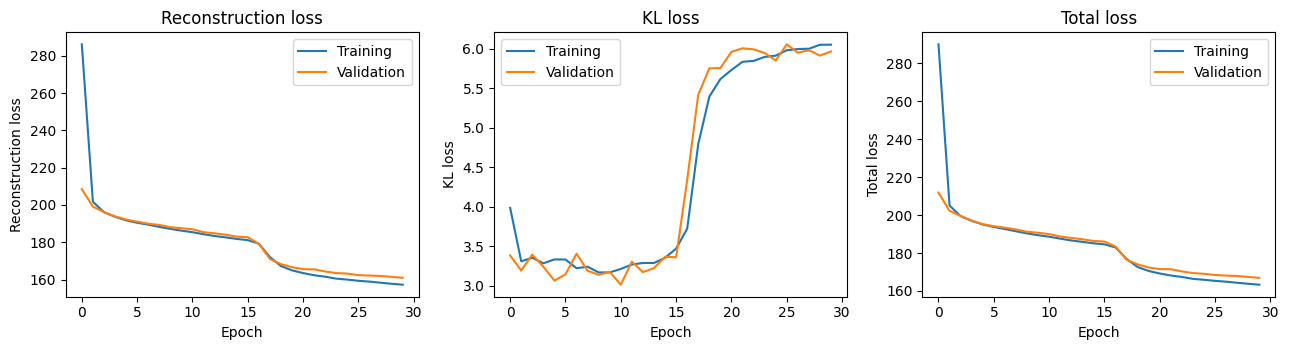

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, key, title in zip(axes, ["rec_loss", "kl_loss", "loss"],
                          ["Reconstruction loss", "KL loss", "Total loss"]):
    ax.plot(vae_hist[key], label="Training"); ax.plot(vae_hist["val_" + key], label="Validation")
    ax.set_xlabel("Epoch"); ax.set_ylabel(title); ax.set_title(title); ax.legend()
savefig("plot_vae_loss")

### VAE test metrics

,Metric,Value
0,Reconstruction Loss,156.153656
1,KL Loss,6.103053
2,Total Loss,162.256709
3,Test MSE,0.046449
4,Test MAE,0.109864
5,Mean SSIM,0.440175


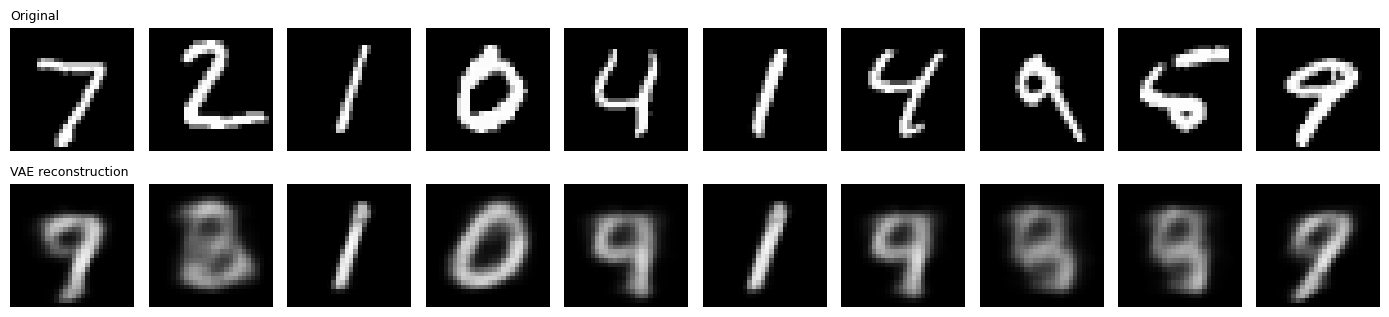

In [ ]:
z_mean_te, z_logvar_te, _ = encoder.predict(x_test, verbose=0)
vae_rec_img = decoder.predict(z_mean_te, verbose=0)      # reconstruction from posterior mean

rec_l, kl_l = [float(v) for v in vae.compute_losses(x_test)]
vae_metrics = evaluate(x_test, vae_rec_img)

vae_table = pd.DataFrame({"Metric": ["Reconstruction Loss", "KL Loss", "Total Loss",
                                     "Test MSE", "Test MAE", "Mean SSIM"],
                          "Value": [rec_l, kl_l, rec_l + kl_l,
                                    vae_metrics["MSE"], vae_metrics["MAE"], vae_metrics["SSIM"]]})
display(vae_table)
vae_table.to_csv("results/vae_metrics.csv", index=False)

results["VAE"] = dict(**vae_metrics, Parameters=encoder.count_params() + decoder.count_params(),
                      Time_s=vae_time)

show_rows([x_test[:10], vae_rec_img[:10]], ["Original", "VAE reconstruction"], name="vae_reconstruction")

### ✍️ Inference – Task 4
Interpret the reconstruction and KL terms during training. Why is the VAE reconstruction blurrier / worse than the CAE? What does the KL term enforce?

> **Write your inference here.**

---
# Task 5 · VAE Latent Space, Generation and Interpolation

### Plot 6 · Two-dimensional latent space (coloured by digit label)

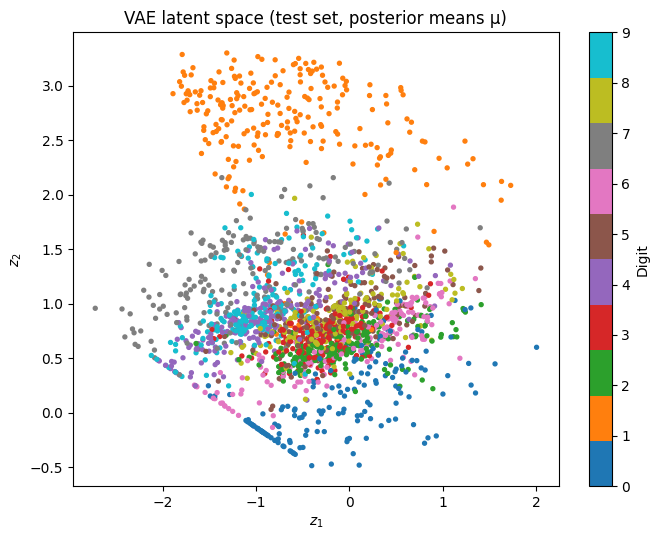

Mean of µ: [-0.436  1.003] | Std of µ: [0.726 0.723]
Mean σ   : [0.089 0.04 ]


In [ ]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(z_mean_te[:, 0], z_mean_te[:, 1], c=y_test, cmap="tab10", s=8)
plt.colorbar(sc, ticks=range(10), label="Digit")
plt.xlabel("$z_1$"); plt.ylabel("$z_2$"); plt.title("VAE latent space (test set, posterior means µ)")
savefig("plot6_vae_latent_space")

print("Mean of µ:", z_mean_te.mean(0).round(3), "| Std of µ:", z_mean_te.std(0).round(3))
print("Mean σ   :", np.exp(0.5 * z_logvar_te).mean(0).round(3))

### Plot 7 · 25 randomly generated digits, z ~ N(0, I)

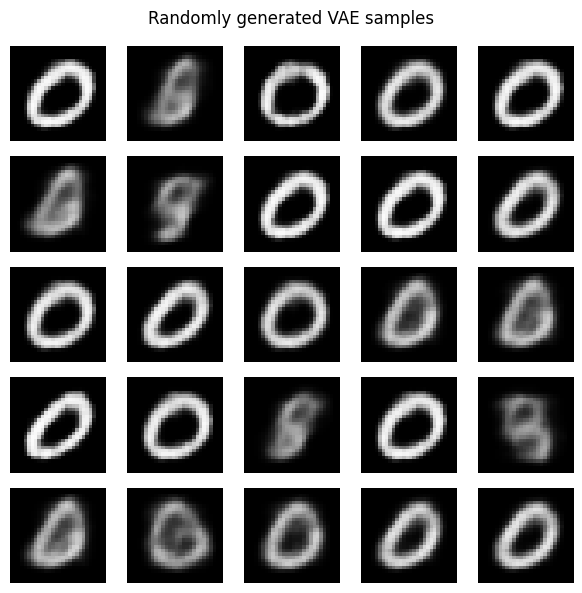

In [ ]:
z_rand = np.random.default_rng(SEED).normal(size=(25, LATENT)).astype("float32")
generated = decoder.predict(z_rand, verbose=0)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for a, im in zip(axes.ravel(), generated):
    a.imshow(im.squeeze(), cmap="gray", vmin=0, vmax=1); a.axis("off")
plt.suptitle("Randomly generated VAE samples")
savefig("plot7_vae_generated")

### Plot 8 · Latent-space interpolation z(α) = (1−α) z_A + α z_B

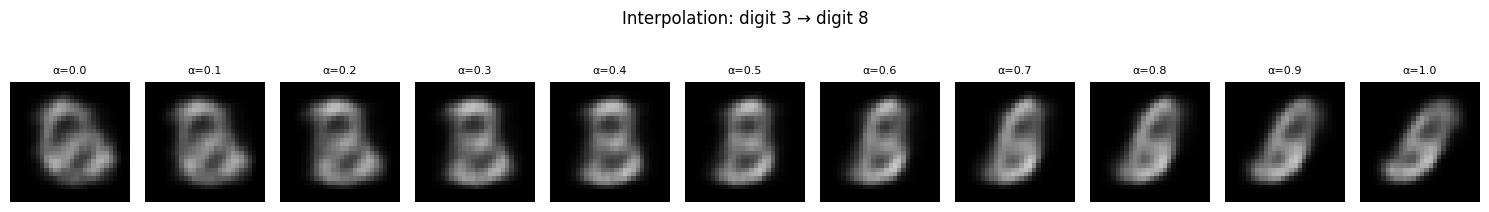

In [ ]:
DIGIT_A, DIGIT_B = 3, 8                      # change to explore other digit pairs
zA = z_mean_te[np.where(y_test == DIGIT_A)[0][0]]
zB = z_mean_te[np.where(y_test == DIGIT_B)[0][0]]

alphas = np.linspace(0, 1, 11)
z_int  = np.array([(1 - a) * zA + a * zB for a in alphas], dtype="float32")
interp = decoder.predict(z_int, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(15, 2))
for a, im, al in zip(axes, interp, alphas):
    a.imshow(im.squeeze(), cmap="gray", vmin=0, vmax=1); a.axis("off"); a.set_title(f"α={al:.1f}", fontsize=8)
plt.suptitle(f"Interpolation: digit {DIGIT_A} → digit {DIGIT_B}", y=1.08)
savefig("plot8_interpolation")

### ✍️ Inference – Task 5
- Latent distribution: is it centred near 0 with roughly unit spread? Do same digits cluster, and which digits overlap?
- Generated samples: recognisable, varied, any ambiguous/unrealistic ones?
- Interpolation: is the transition smooth or abrupt?
- Deterministic (AE) vs probabilistic (VAE) latent representation.

> **Write your inference here.**

---
# Task 6 · Reconstruction-Error Distribution and High-Error Images
Per-image error e_i = (1/D) Σ_j (x_ij − x̂_ij)².

[FC_AE] mean=0.02046  median=0.01932  std=0.01066  5–95% range=(0.00435, 0.03936)  max=0.06911


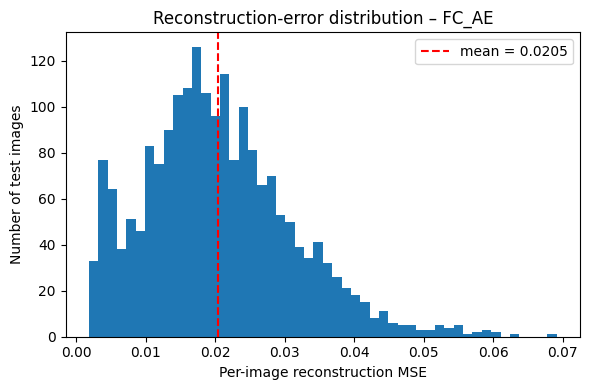

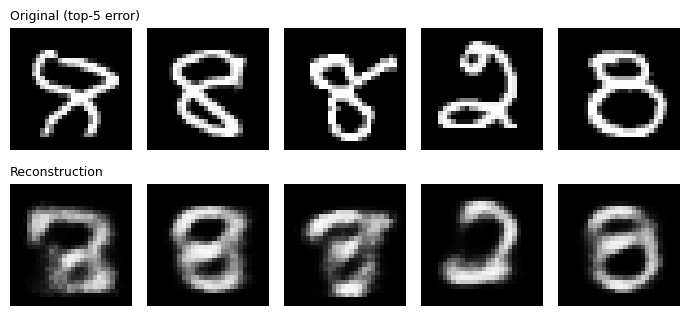

,Sample,Test index,Digit,Error
0,1,1782,8,0.06911
1,2,1758,8,0.06298
2,3,1170,8,0.06103
3,4,744,2,0.06076
4,5,338,8,0.05965


In [ ]:
def error_analysis(x, xh, tag):
    e = per_image_mse(x, xh)
    print(f"[{tag}] mean={e.mean():.5f}  median={np.median(e):.5f}  std={e.std():.5f}  "
          f"5–95% range=({np.percentile(e,5):.5f}, {np.percentile(e,95):.5f})  max={e.max():.5f}")

    plt.figure(figsize=(6, 4))
    plt.hist(e, bins=50)
    plt.axvline(e.mean(), color="r", ls="--", label=f"mean = {e.mean():.4f}")
    plt.xlabel("Per-image reconstruction MSE"); plt.ylabel("Number of test images")
    plt.title(f"Reconstruction-error distribution – {tag}"); plt.legend()
    savefig(f"plot9_error_hist_{tag}")

    top = np.argsort(e)[-5:][::-1]
    show_rows([x[top], xh[top]], ["Original (top-5 error)", "Reconstruction"], n=5,
              name=f"high_error_{tag}")
    display(pd.DataFrame({"Sample": range(1, 6), "Test index": top,
                          "Digit": y_test[top], "Error": e[top].round(5)}))
    return e

e_fc  = error_analysis(x_test, fc_rec,  "FC_AE")

[CAE] mean=0.00260  median=0.00236  std=0.00143  5–95% range=(0.00066, 0.00523)  max=0.01264


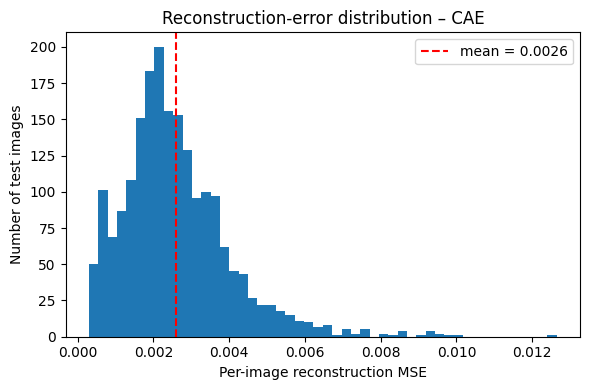

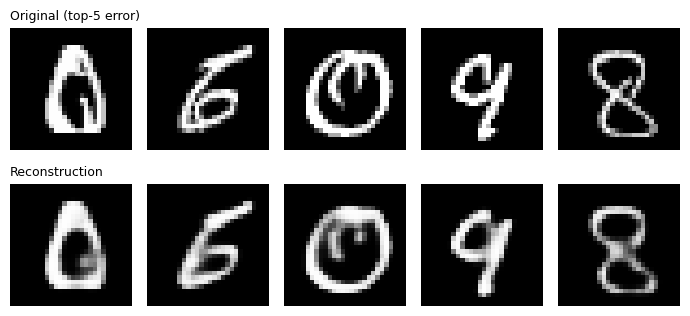

,Sample,Test index,Digit,Error
0,1,895,0,0.01264
1,2,1982,6,0.01005
2,3,1526,0,0.00993
3,4,1594,9,0.00957
4,5,431,8,0.00952


In [ ]:
e_cae = error_analysis(x_test, cae_rec, "CAE")

### ✍️ Inference – Task 6
Typical error range, concentrated vs spread distribution, characteristics of the five worst images (unusual writing style, thick strokes, rare shapes…), and the relationship between error and visual quality.

> **Write your inference here.**

---
# Task 7 · Latent-Dimension Study (Basic FC Autoencoder)
d_z ∈ {2, 8, 16, 32}

In [ ]:
lat_rows = []
for dz in [2, 8, 16, 32]:
    m, _, _ = train_fc(dz)
    rec = m.predict(flat(x_test), verbose=0).reshape(-1, 28, 28, 1)
    met = evaluate(x_test, rec)
    lat_rows.append(dict(**{"Latent Dimension": dz}, MSE=met["MSE"], SSIM=met["SSIM"],
                         Parameters=m.count_params()))
    print(f"d_z = {dz:2d}  MSE = {met['MSE']:.5f}  SSIM = {met['SSIM']:.4f}")

lat_df = pd.DataFrame(lat_rows)
lat_df.to_csv("results/latent_dim_study.csv", index=False)
display(lat_df)

d_z =  2  MSE = 0.04586  SSIM = 0.4548
d_z =  8  MSE = 0.02640  SSIM = 0.6927
d_z = 16  MSE = 0.02145  SSIM = 0.7441
d_z = 32  MSE = 0.02018  SSIM = 0.7613


,Latent Dimension,MSE,SSIM,Parameters
0,2,0.045864,0.454819,210130
1,8,0.026398,0.692656,210520
2,16,0.021450,0.744100,211040
3,32,0.020183,0.761310,212080


### Plot 10 · Latent dimension vs reconstruction MSE

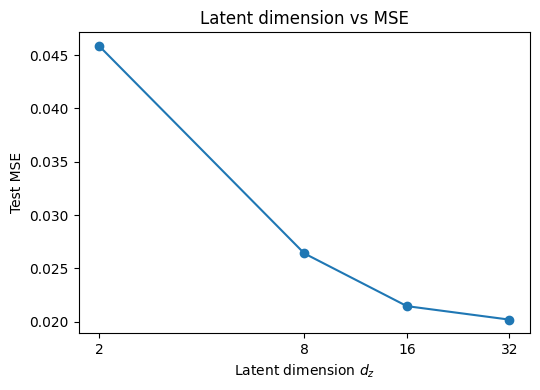

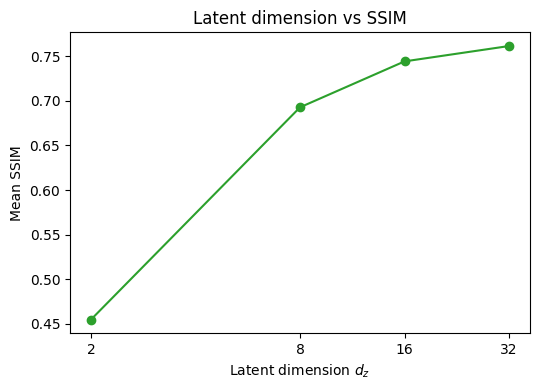

In [ ]:
plt.figure(figsize=(5.5, 4))
plt.plot(lat_df["Latent Dimension"], lat_df["MSE"], "o-")
plt.xscale("log", base=2); plt.xticks(lat_df["Latent Dimension"], lat_df["Latent Dimension"])
plt.xlabel("Latent dimension $d_z$"); plt.ylabel("Test MSE"); plt.title("Latent dimension vs MSE")
savefig("plot10_latent_dim_vs_mse")

plt.figure(figsize=(5.5, 4))
plt.plot(lat_df["Latent Dimension"], lat_df["SSIM"], "o-", color="tab:green")
plt.xscale("log", base=2); plt.xticks(lat_df["Latent Dimension"], lat_df["Latent Dimension"])
plt.xlabel("Latent dimension $d_z$"); plt.ylabel("Mean SSIM"); plt.title("Latent dimension vs SSIM")
savefig("plot10b_latent_dim_vs_ssim")

### ✍️ Inference – Task 7
Explain the compression vs reconstruction-quality trade-off. What happens when d_z is too small? Are there diminishing returns as d_z increases?

> **Write your inference here.**

---
# Task 8 · Consolidated Results

In [ ]:
cons = pd.DataFrame(results).T[["MSE", "MAE", "SSIM", "Parameters", "Time_s"]]
cons.columns = ["MSE", "MAE", "SSIM", "Parameters", "Time (s)"]
cons["Parameters"] = cons["Parameters"].astype(int)
display(cons.round(5))
cons.to_csv("results/consolidated_results.csv")

,MSE,MAE,SSIM,Parameters,Time (s)
FC Autoencoder,0.02046,0.05510,0.75871,211040,15.89406
Conv. Autoencoder,0.00260,0.01509,0.97352,74497,18.97910
Denoising CAE,0.00473,0.02150,0.94434,74497,23.25659
VAE,0.04645,0.10986,0.44017,134165,27.26416


> **Notes for the report**
> - FC-AE, CAE: reconstruction of the clean test image.  
> - Denoising CAE: reconstruction of the clean image from a Gaussian σ = 0.2 noisy input.  
> - VAE: MSE/MAE/SSIM computed from the decoded posterior mean; its total objective also contains the KL term (reported in Task 4).  
> - VAE parameters = encoder + decoder.

## Final Written Inferences (mandatory)
For each item write: **what the plot shows → trend → why → conclusion**.

1. Effect of latent dimension on reconstruction  
2. Difference between fully connected and convolutional reconstruction  
3. Effect of Gaussian noise level  
4. Ability of the DAE to recover image structure  
5. Characteristics of the VAE latent distribution  
6. Structure of the 2-D VAE latent space  
7. Quality and diversity of generated samples  
8. Smoothness of latent-space interpolation  
9. Relationship between reconstruction error and visual quality  
10. Deterministic vs probabilistic latent representations  

> **Write your answers here.**

## Discussion Questions
Answer Questions 1–25 from Section 28 of the lab manual in this cell or a separate document.

## Additional Exercises (optional)
- Latent dimensions 4/8/16/32 for the CAE (reuse `build_cae` with a bottleneck of the required size).  
- Effect of KL weight: `VAE(encoder, decoder, beta=4.0)`; re-train and compare latent space and samples.  
- VAE with `LATENT = 8`: change the constant in Task 4 and re-run.  
- Interpolation between other digit regions: change `DIGIT_A`, `DIGIT_B` in Task 5.